# **Arco Diurno**

El movimiento aparente de un objeto de la esfera celeste, es visto por un observador en la Tierra, mediante un arco sobre el horizonte llamado ``arco diurno``. 

La posición horizontal del objeto, que depende del tiempo, se mide mediante su ángulo horario $h$. Un ángulo horario de $24 h$ corresponde a un círculo completo de $360^\circ$ paralelo al ecuador celeste.Por esta razón, $h$ puede expresarse de forma equivalente en grados o radianes. 

<div style="text-align:center;">
<img src="arco_diurno.png" alt="Ejemplo" width="400">
</div>

#### **Nota importante**

Un ángulo horario de $1 h$ no equivale a una diferencia horaria de una hora solar. 


Por definición, el ``ángulo horario`` es cero cuando el objeto alcanza la mayor altitud sobre el horizonte.

El ángulo horario correspondiente a la puesta del sol, cuando el objeto desaparece justo bajo el horizonte, viene dado por:

$$
\cos{h_{set}}=-\tan{(\delta)}tan{(\phi)}
$$

Dado que el plano ecuatorial está inclinado un ángulo de $90^\circ − \phi$ con respecto al plano horizontal, la culminación superior de la estrella en el meridiano viene dada por $a_{max} = 90^\circ − \phi + \delta$, donde $\delta$ es la declinación. y $\phi$ es la latitud del observador.

En el sistema de rotación conjunta, la estrella sale con un ángulo horario $h_{rise}$, alcanza su mayor altitud cuando cruza el meridiano en $h = 0$ y se pone en el horizonte en $h_{set} = −h_{rise}$.

#### **El Tiempo Cideral**

La variable $T = 2h_{set}$ mide el llamado ``tiempo sideral`` durante el cual el objeto es, en principio, visible en el cielo (las estrellas, por supuesto, son eclipsadas por el Sol durante el día).

También se conoce como ``longitud del arco diurno``. 

### **Ejemplo de la estrella Betelgeuse**

Betelgeuse es una gigante roja que se encuentra entre las estrellas más brillantes del cielo en la constelación de Orión.

Su declinación se puede encontrar fácilmente con la ayuda de ``astropy.coordinates``, que ofrece una función que busca el nombre de un objeto en bases de datos en línea:

In [4]:
pip install astropy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
from astropy.coordinates import SkyCoord, EarthLocation

betelgeuse=SkyCoord.from_name("Betelgeuse")
print(betelgeuse)

<SkyCoord (ICRS): (ra, dec) in deg
    (88.79293899, 7.407064)>


Esto nos indica que la ``ascensión recta (ra)`` y la ``declinación (dec)`` del objeto llamado Betelgeuse resultaron ser 88,79° y 7,41°, respectivamente. El atributo ``dec`` nos permite hacer referencia directa a la declinación:

In [15]:
delta=betelgeuse.dec
print(delta)

7d24m25.4304s


donde:
$$
\delta \approx +07^{\circ} \, 24^{\prime} \, 25^{\prime\prime}, 
\quad \text{donde } 1^{\prime} = \frac{1}{60}^{\circ}, \; 
1^{\prime\prime} = \frac{1}{60}^{\prime}
$$




### **Cálculo del Arco Diurno en una localización de la Tierra**

Supongamos que se desea determinar la longitud del arco diurno de Betelgeuse visto desde el Observatorio de Hamburgo $(\phi \approx +53^\circ 28^′ 49^{′′})$. 


Además de la declinación de la estrella, necesitamos la posición del observador. El equivalente de ``SkyCoord`` para coordenadas celestes es ``EarthLocation``, que nos permite establecer la latitud y longitud geográficas de una ubicación en la Tierra:

In [16]:
from astropy.coordinates import EarthLocation
import astropy.units as u

#Debemos capturar la posicion geografica del observador, para ello se utiliza la latitud y la longitud:

obs=EarthLocation(lat=53*u.deg + 28*u.arcmin + 49*u.arcsec,
                  lon=10*u.deg+14*u.arcmin+23*u.arcsec)

#Este valor se lo pasamos al valor de phi
phi=obs.lat

- En las expresiones anteriores, ``u.deg`` es equivalente a $1^\circ$, ``u.arcmin`` es $1^′$ y ``u.arcsec`` es $1^{′′}$. 

- El módulo ``units`` de astropy implementa reglas para realizar cálculos en sistemas de unidades físicas y astronómicas. 

A continuación, calculamos h con la ayuda de funciones trigonométricas del módulo math:

In [17]:
import math

h=math.acos(-math.tan(delta.radian) *math.tan(phi.radian))

Es necesario convertir los ángulos $δ$ y $φ$ a radianes antes de aplicar la función tangente ``math.tan()``. Con las coordenadas de Astropy, todo lo que necesitamos hacer es usar el hecho de que un ángulo de 360° (una rotación completa de la Tierra) corresponde a un día sideral, que es aproximadamente 4 minutos más corto que un día solar. 

Esto es consecuencia del movimiento orbital de la Tierra. La conversión se simplifica mediante el módulo de unidades:

In [18]:
T =(math.degrees(2*h)/360)*u.sday
print("T = {:.2f}".format(T.to(u.h)))

T = 13.31 h


Si no fuera por el Sol, Betelgeuse podría ser visto a las ``13 horas`` desde el Observatorio. Por supuesto, la estrella será visible solo durante la superposición entre este período y la noche, que depende de la fecha. 

### **Cálculo del periodo de luz para cualquier día del año**

El arco diurno del Sol juega un papel central en nuestra vida diaria, ya que determina el período de luz del día. Para calcularlo, debemos realizar lo siguiente:


In [29]:
import numpy as np
import math

#Primero calculamos lel arco diurno del sol

N=np.arange(365) #Generamos una lista que inicia en 0 y termina en 364
omega=2*math.pi/365.24
ecli=math.degrees(23.44)

delta =-np.arcsin(math.sin(ecli)* np.cos(omega*(N+10)))

Ahora calculamos el valor de $h$ para el arco diurno, al igual debemos utilizar una posicion especifica $\phi$ para una determinada posición de la Tierra, ya que dependiendo de la locaclización, el periodo del día es distinto:

In [30]:
# calcular el periodo del dia en horas solares
h= np.arccos(-np.tan(delta)*math.tan(phi.radian))  #tomamos el valor phi para el observatorio anterior
T =(np.degrees(2*h)/360) * u.sday.to(u.h)

C:\Users\jim\AppData\Local\Temp\ipykernel_6340\1582239069.py:2: RuntimeWarning: invalid value encountered in arccos
  h= np.arccos(-np.tan(delta)*math.tan(phi.radian))  #tomamos el valor phi para el observatorio anterior


### **Ploteo de datos**

- Al trabajar con grandes conjuntos de datos (es decir, con más de unos pocos valores), suele ser preferible extraer algunas estadísticas o mostrar los datos gráficamente.

- Para mostrar la variación anual de la duración del día, lo más lógico es generar un gráfico de T frente a N. La biblioteca ``matplotlib`` de Python ``(seematplotlib.org)`` proporciona un módulo llamado ``pyplot`` para graficar datos en matrices:


Text(0, 0.5, 'Periodo del dia [h]')

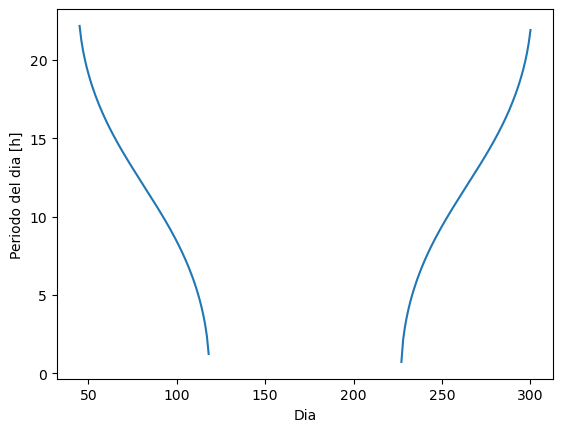

In [31]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(N, T)
plt.xlabel("Dia")
plt.ylabel("Periodo del dia [h]")


La duración del día es corta en enero, alcanza un máximo en el primer solsticio (N = 171) y luego disminuye hasta llegar al segundo solsticio en N = 355. La duración mínima y máxima del día se puede inferir con la ayuda de los métodos ``min()`` y ``max()`` para matrices de numpy

In [32]:
print("Valor minimo del dia: {:5.2f}".format(T.min()) )
print("Valor minimo del dia: {:5.2f}".format(T.max()))

Valor minimo del dia:   nan
Valor minimo del dia:   nan
